# Regression Task

Datasource: [Ames Housing Dataset](https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset)

# Table of Contents

1. [Data Inspection](#data-inspection)
- This section provides a comprehensive review of the dataset. We ensure the data is ready for analysis by addressing issues such as incorrect data, handling missing values through various strategies (like imputation or removal), dealing with duplicate entries, rectifying case inconsistencies, managing mixed data types through feature engineering.

2. [Univariate Analysis](#uni-variate-analysis)
- This section focuses on the independent analysis of variables. We understand their distribution through visualizations like histograms and bar charts. This helps us understand the central tendency and dispersion of individual variables.

3. [Bivariate Analysis](#bi-variate-analysis)
- This section delves into the exploration of relationships between pairs of variables. It includes the creation of scatter plots, correlation matrices, and other visualizations to comprehend the interplay between variables. This helps us understand the relationships and dependencies between different variables.

4. [Outlier Detection](#outliers)
- This section is dedicated to the identification of outliers. It explores the assumptions of various outlier removal methods, ranging from the z-score to the IQR method. This helps us ensure that our data is not skewed by extreme values.

5. [Feature Engineering](#feature-engineering)
- This section is about generating new features from existing ones to enhance the performance of machine learning models. It encompasses techniques like binning, creation of polynomial features, and interaction features. This helps us extract more information from our data and improve the predictive power of our models.

6. [Feature Selection](#feature-selection)
- This section is about choosing the most informative features for modeling. It includes techniques like mutual information and chi-square tests. This helps us reduce the dimensionality of our data and focus on the most important features.

7. [Conclusion](#conclusion)
- This section encapsulates the insights from the EDA, discusses their impact on modeling, and outlines the future steps in the project. This helps us summarize our findings and plan our next steps.

8. [Model Scoping with Pycaret](#quick-model-scoping-with-pycaret)
- This section involves a rapid scoping of various machine learning models using the Pycaret library. It includes the setup of the environment, model comparisons, and tuning of the best model. This helps us quickly identify promising models.

9. [Modelling](#modelling)
- This section involves the application of different transformations to our data with the assistance of the pipeline class. This includes scaling features, encoding categorical variables, and applying various machine learning algorithms. This helps us build and evaluate our final models.

10. [Stacking](#stacking-meta-learner)
- This involves training multiple different models (base models) and then adding a new model (meta-learner or second-level model) on top that is trained to make a final prediction based on the predictions of the base models. The base models are trained based on a complete training set, then the meta-learner model is trained to make a final prediction based on the predictions of the base models. This can lead to improved predictive performance.

12. [Voting](#voting-regressor) 
- The idea behind the Voting Regressor is to combine conceptually different machine learning regressors and return the average predicted values. Such a regressor can be useful for a set of equally well performing models in order to balance out their individual weaknesses.

13. [Blending](#blending)
- Combining different models together! 

14. [Visualisation](#visualisation)
- This section involves visualising the best pipeline, the transformations and model, along with the feature importance.

# Library Imports

In [1]:
# Third-party library imports for data loading and numerical operations
import numpy as np
import pandas as pd

# Third-party library imports for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Third-party library imports for statistical analysis
import scipy
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# Third-party library imports for feature engineering
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Set configuration for sklearn
set_config(display='diagram', transform_output='pandas') 

# Loading the dataset

In [2]:
train = pd.read_csv('data/raw/train.csv')
test = pd.read_csv('data/raw/test.csv')
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print (f"Train has {train.shape[0]} rows and {train.shape[1]} columns")
print (f"Test has {test.shape[0]} rows and {test.shape[1]} columns")

Train has 1460 rows and 81 columns
Test has 1459 rows and 80 columns


Now, we have two seperate datasets, ```train``` and ```test```, common in many Kaggle competitions, which complicates things for 2 reasons.

Firstly, excluding the test data from exploratory data analysis (EDA) limits our understanding of the overall dataset distribution and potential patterns. This restriction may result in missing valuable insights that could enhance model performance.

Secondly, the preprocessing steps applied to the train dataset need to be replicated for the test dataset. This process introduces complexity and increases the likelihood of errors, especially if the preprocessing steps are not implemented consistently across both datasets.

To address these challenges, a solution involves concatenating the training and test datasets into a single dataframe. This combined dataset, referred to as ```x_all```, allows us to perform EDA on the entire dataset, enabling a comprehensive analysis that incorporates all available information.

Furthermore, by applying the same preprocessing steps to ```x_all```, we ensure consistency in data transformation across both the training and test datasets. Once preprocessing is complete, we can easily split ```x_all``` back into the original ```train``` and ```test``` datasets for subsequent model training and evaluation.

In [4]:
all_ids = pd.concat([train['Id'], test['Id']], ignore_index=True)
assert all_ids.is_unique, "'Id' column in the combined dataset has duplicate values, cannot be used as index."

# Subtract 1 from the 'Id' column (since index starts from 0) and set it as the index for train and test
train = train.set_index(train['Id'] - 1)
test = test.set_index(test['Id'] - 1)

# Drop the 'Id' column as it's now the index
train = train.drop('Id', axis=1)
test = test.drop('Id', axis=1)

# Concatenate train and test
x_all = pd.concat([train.drop("SalePrice", axis=1), test], axis=0)

# Get the target variable from train
y_train = train[['SalePrice']]

# Data Inspection

In [5]:
x_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 0 to 2918
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   int64  
 1   MSZoning       2915 non-null   object 
 2   LotFrontage    2433 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          198 non-null    object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2917 non-null   object 
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuilt    

### Checking for duplicate rows

In [6]:
duplicate_rows = x_all.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

Number of duplicate rows: 2


### Checking for missing values

In [7]:
# Calculate missing data
missing_data = x_all.isnull().sum()
missing_data = missing_data[missing_data > 0]  # Only consider columns with missing data
missing_percentage = (missing_data / len(x_all)) * 100

# Combine the count and percentage into a DataFrame for nicer formatting
missing_df = pd.DataFrame({'Count': missing_data, 'Percentage': missing_percentage})

# Sort by percentage of missing values
missing_df = missing_df.sort_values(by='Percentage', ascending=False)

print("Columns with missing data, their count and percentage:")
missing_df

Columns with missing data, their count and percentage:


,Count,Percentage
PoolQC,2909,99.657417
MiscFeature,2814,96.402878
Alley,2721,93.216855
Fence,2348,80.438506
MasVnrType,1766,60.500171
FireplaceQu,1420,48.646797
LotFrontage,486,16.649538
GarageFinish,159,5.447071
GarageQual,159,5.447071
GarageCond,159,5.447071


A significant number of columns in this dataset contain missing data. It's particularly notable that six columns have more than 15% of their values missing. The reasons for missing data can vary widely, from human error to other factors. However, in this dataset, it's important to note that for some features, the "NA" value is meaningful. For instance, in the 'PoolQC' feature, which represents pool quality, "NA" indicates the absence of a pool.

```PoolQC```: Pool quality
- Ex - Excellent
- Gd - Good
- TA - Average/Typical
- Fa - Fair
- NA - No Pool

In the subsequent steps, we will address these missing values by imputing them with appropriate values.

### Checking for constant values (no-variance features)

In [8]:
constant_columns = [col for col in x_all.columns if x_all[col].nunique() <= 1]
print(f"Columns with constant values: {constant_columns}")

Columns with constant values: []


### Checking for mixed types

In [9]:
# # Iterate over the columns
# for column in x_all.columns:
#     # Get the unique types of the column values
#     unique_types = set(x_all[column].apply(type))
    
#     # If more than one unique type is found, print the column name and the unique values of each type
#     if len(unique_types) > 1:
#         print(f"{column} contains mixed types: {unique_types}")
#         for value_type in unique_types:
#             print(f"Unique {value_type} values: {x_all[column].apply(lambda x: x if type(x) == value_type and not pd.isnull(x) else None).dropna().unique()}")

### Checking for inconsistent values

In [10]:
# Check for negative values in numerical columns
numerical_cols = x_all.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if train[col].lt(0).any():
        print(f"Column {col} contains negative values")

### Checking for formatting errors (case inconsistency)

In [11]:
categorical_cols = x_all.select_dtypes(include=['object']).columns
# Check for case inconsistency in categorical columns
for col in categorical_cols:
    # Convert all values to lower case and check if the number of unique values decreases
    num_unique_values_original = x_all[col].nunique()
    num_unique_values_lower = x_all[col].str.lower().nunique()
    if num_unique_values_lower < num_unique_values_original:
        print(f"Column {col} has case inconsistency")

### Transforming Features to Their Appropriate Types

In general, we can classify features in our dataset into three main types:

* **Continuous**: These are numeric variables that can take an infinite number of values between any two values. They are often visualized using histograms and scatter plots, and can be transformed via methods such as scaling and normalization.

* **Ordinal**: These are variables that have two or more categories, but the categories have an inherent order. For example, a feature like 'education level', with values like 'high school', 'bachelor's degree', 'master's degree', would be an ordinal feature. These are often visualized using bar charts or line plots, and can be processed using methods such as label encoding.

* **Categorical/Nominal**: These are variables that have two or more categories but without any kind of order or priority. For example, a feature like 'color', with values like 'red', 'blue', 'green', would be a categorical feature. These are often visualized using bar charts or pie charts, and can be processed using methods such as one-hot encoding.

Separating the types of features is beneficial for our Exploratory Data Analysis (EDA), as we utilize different visualization methods for each type, depending on the nature of the problem and the target variable.

Moreover, different types of preprocessing methods are applied to each feature type. For instance, continuous features might be scaled to a standard range, ordinal features might be label encoded, and categorical features might be one-hot encoded. This ensures that our machine learning algorithms can interpret the features correctly.

In [12]:
x_all = x_all.replace({"MSSubClass" : {20 : "SC20", 30 : "SC30", 40 : "SC40", 45 : "SC45", 
                                       50 : "SC50", 60 : "SC60", 70 : "SC70", 75 : "SC75", 
                                       80 : "SC80", 85 : "SC85", 90 : "SC90", 120 : "SC120", 
                                       150 : "SC150", 160 : "SC160", 180 : "SC180", 190 : "SC190"},
                        "MoSold" : {1 : "Jan", 2 : "Feb", 3 : "Mar", 4 : "Apr", 5 : "May", 6 : "Jun",
                                    7 : "Jul", 8 : "Aug", 9 : "Sep", 10 : "Oct", 11 : "Nov", 12 : "Dec"}
                        })

The ```MSSubClass``` and ```MoSold``` features, originally numerical, are being converted to categorical. ```MSSubClass``` represents the building class with different numerical codes, which are now prefixed with 'SC' to indicate them as separate categories. ```MoSold```, initially represented as numbers from 1 to 12, is transformed to corresponding month abbreviations, turning it into a nominal feature.

In [13]:
# Encode some categorical features as ordinal ordered numbers when there is information in the order
x_all = x_all.replace({"Alley" : {np.nan: 0, "Grvl" : 1, "Pave" : 2},
                       "BsmtCond" : {np.nan : 0, "Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5},  # BsmtQual: Evaluates the height of the basement
                       "BsmtExposure" : {np.nan : 0, "No": 1, "Mn" : 2, "Av": 3, "Gd" : 4}, #BsmtExposure: Refers to walkout or garden level walls
                       "BsmtFinType1" : {np.nan : 0, "Unf" : 1, "LwQ": 2, "Rec" : 3, "BLQ" : 4, "ALQ" : 5, "GLQ" : 6}, #BsmtFinType1: Rating of basement finished area
                       "BsmtFinType2" : {np.nan: 0, "Unf" : 1, "LwQ": 2, "Rec" : 3, "BLQ" : 4, "ALQ" : 5, "GLQ" : 6}, #BsmtFinType2: Rating of basement finished area (if multiple types)
                       "BsmtQual" : {np.nan : 0, "Po" : 1, "Fa" : 2, "TA": 3, "Gd" : 4, "Ex" : 5}, #BsmtQual: Evaluates the height of the basement
                       "ExterCond" : {"Po" : 1, "Fa" : 2, "TA": 3, "Gd": 4, "Ex" : 5}, #ExterCond: Evaluates the present condition of the material on the exterior
                       "ExterQual" : {"Po" : 1, "Fa" : 2, "TA": 3, "Gd": 4, "Ex" : 5}, #ExterQual: Evaluates the quality of the material on the exterior
                       "FireplaceQu" : {np.nan : 0, "Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}, #FireplaceQu: Fireplace quality
                       "Functional" : {"Sal" : 1, "Sev" : 2, "Maj2" : 3, "Maj1" : 4, "Mod": 5, "Min2" : 6, "Min1" : 7, "Typ" : 8}, # Home functionality (Assume typical unless deductions are warranted)
                       "GarageCond" : {np.nan : 0, "Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}, #GarageCond: Evaluates the present condition of the garage
                       "GarageQual" : {np.nan : 0, "Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}, #GarageQual: Garage quality
                       "HeatingQC" : {"Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}, #HeatingQC: Heating quality and condition
                       "KitchenQual" : {"Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}, #KitchenQual: Kitchen quality
                       "LandSlope" : {"Sev" : 1, "Mod" : 2, "Gtl" : 3}, #LandSlope: Slope of property
                       "LotShape" : {"IR3" : 1, "IR2" : 2, "IR1" : 3, "Reg" : 4},  #LotShape: General shape of property
                       "PavedDrive" : {"N" : 0, "P" : 1, "Y" : 2}, #PavedDrive: Paved driveway
                       "PoolQC" : {np.nan : 0, "Fa" : 1, "TA" : 2, "Gd" : 3, "Ex" : 4}, #PoolQC: Pool quality
                       "Street" : {"Grvl" : 1, "Pave" : 2}, #Street: Type of road access
                       "Utilities" : {"ELO" : 1, "NoSeWa" : 2, "NoSewr" : 3, "AllPub" : 4}, #Utilities: Type of utilities available
                       "Fence": {np.nan : 0, "GdPrv": 1, "MnPrv": 2, "GdWo": 3, "MnWw": 4}} #Fence: Fence quality
                     )

# EDA
With our dataset now cleaned and preprocessed, we can proceed to the EDA phase. Before diving into the analysis, we'll first categorize our features into three groups: continuous, ordinal, and categorical. This classification allows us to employ different visualization methods tailored to the nature of each feature type.

In [14]:
numerical_cols = x_all.select_dtypes(include=[np.number]).columns
categorical_cols = x_all.select_dtypes(include=['object']).columns

ordinal_features = ['Alley', 
                    'BsmtCond', 
                    'BsmtExposure', 
                    'BsmtFinType1', 
                    'BsmtFinType2', 
                    'BsmtQual', 
                    "ExterCond", 
                    "ExterQual", 
                    "FireplaceQu", 
                    "Functional", 
                    "GarageCond", 
                    "GarageQual", 
                    "HeatingQC", 
                    "KitchenQual", 
                    "LandSlope", 
                    "LotShape", 
                    "PavedDrive", 
                    "PoolQC", 
                    "Street", 
                    "Utilities",
                    'OverallQual',
                    'OverallCond',
                    'BsmtFullBath',
                    'BsmtHalfBath',
                    'FullBath',
                    'HalfBath',
                    'BedroomAbvGr', 
                    'KitchenAbvGr', 
                    'TotRmsAbvGrd', 
                    'Fireplaces', 
                    'GarageCars',
                    'Fence']

# Check if any of the ordinal columns are not in the numerical or categorical columns
continuous_features = [col for col in numerical_cols if col not in ordinal_features]
categorical_features = [col for col in categorical_cols if col not in ordinal_features]

Histograms and box plots are excellent tools for visualizing continuous variables.

Histograms provide a visual interpretation of numerical data by indicating the number of data points that lie within a range of values, known as a bin. They effectively represent the underlying frequency distribution (shape) of a set of continuous data. This allows the inspection of the data for its underlying distribution (e.g., normal distribution), outliers, skewness, etc.

Box plots, on the other hand, provide a summary of the statistical data through their quartiles. They also identify outliers within the data. The line in the middle of the box is the median of the data, and the box represents the interquartile range (from the first quartile to the third quartile), giving a quick graphical representation of the center and spread of the data.

For ordinal and categorical variables, bar plots are used.

Bar plots are useful for displaying and comparing the quantity, frequency, or other measure (e.g., mean) for different categories or groups. The x-axis represents the categories and the y-axis represents the quantity. This makes it easy to compare quantities for different categories in the data and can highlight significant differences between categories.

In [15]:
def uni_hist_plot(data, continuous_features, plot_num_cols=3):
    num_plots = len(continuous_features)
    total_cols = plot_num_cols
    total_rows = num_plots // total_cols + 1

    fig = make_subplots(rows=total_rows, cols=total_cols)

    for i, var in enumerate(continuous_features):
        row = i // total_cols + 1
        pos = i % total_cols + 1
        fig.add_trace(go.Histogram(x=train[var], nbinsx=50, name=var), row=row, col=pos)

    fig.update_layout(height=300*total_rows, width=400*total_cols, title_text="Distribution of continuous features")
    fig.show()

def uni_box_plot(data, continuous_features, plot_num_cols=3):
    num_plots = len(continuous_features)
    total_cols = plot_num_cols
    total_rows = num_plots // total_cols + 1

    fig = make_subplots(rows=total_rows, cols=total_cols)

    for i, var in enumerate(continuous_features):
        row = i // total_cols + 1
        pos = i % total_cols + 1
        fig.add_trace(go.Box(y=train[var], name=var), row=row, col=pos)

    fig.update_layout(height=300*total_rows, width=400*total_cols, title_text="Boxplot of continuous features")
    fig.show()

def uni_count_plot(data, categorical_features, plot_num_cols=3):
    num_plots = len(categorical_features)
    total_cols = plot_num_cols
    total_rows = num_plots // total_cols + 1

    fig = make_subplots(rows=total_rows, cols=total_cols)

    for i, var in enumerate(categorical_features):
        row = i // total_cols + 1
        pos = i % total_cols + 1
        fig.add_trace(go.Bar(x=data[var].value_counts().index, y=data[var].value_counts().values, name=var), row=row, col=pos)

    fig.update_layout(height=300*total_rows, width=400*total_cols, title_text="Count of categorical features")
    fig.show()

## Uni-variate Analysis

### Target Variable - SalePrice

In [16]:
y_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

/Users/lowrenhwa/Desktop/house_prices_advanced_regression_techniques/.venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


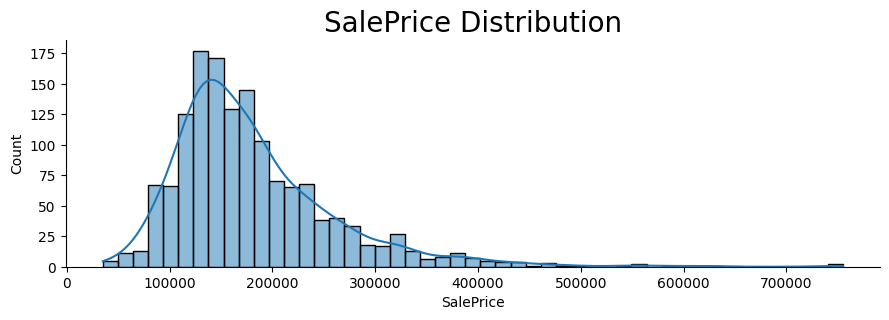

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


In [17]:
sns.displot(y_train['SalePrice'], kde=True, height=3, aspect=3)
plt.title('{} Distribution'.format('SalePrice'), fontsize=20)
plt.show()

# skewness and kurtosis
print("Skewness: " + str(y_train['SalePrice'].skew()))
print("Kurtosis: " + str(y_train['SalePrice'].kurt()))

Skewness measures the asymmetry of a probability distribution about its mean. Positive skewness indicates a distribution with an asymmetric tail extending towards more positive values. The skewness of 1.88 for ```SalePrice``` suggests that the distribution is moderately positively skewed. This means that most of the houses are sold at a price below the average, with a few houses sold at much higher prices.

Kurtosis measures the "tailedness" of the probability distribution. A kurtosis of 6.54 indicates that the ```SalePrice``` distribution has heavier tails and a sharper peak than the normal distribution. In other words, it has more outliers (values that are significantly higher or lower than the mean) and the values are more concentrated around the mean.

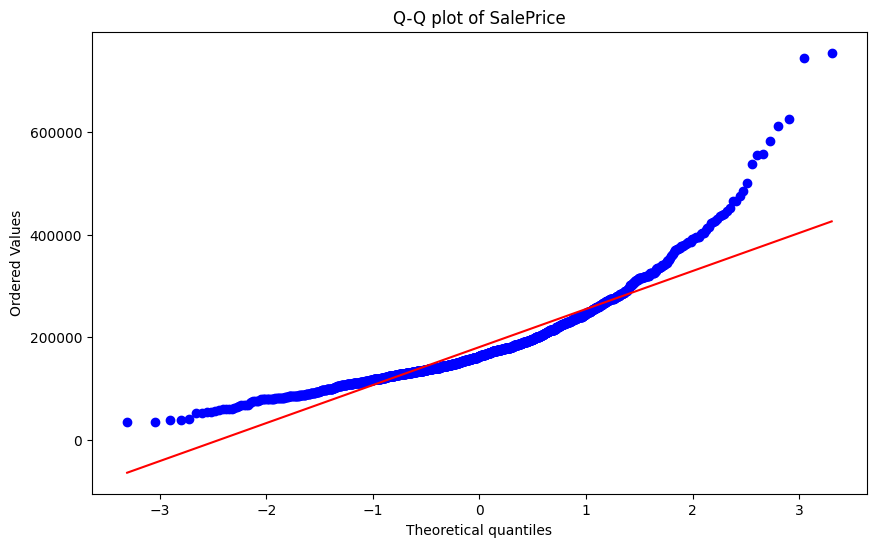

Statistics=0.870, p=0.000
The 'SalePrice' variable does not appear to follow a Gaussian distribution (reject H0)


In [18]:
# Q-Q plot
plt.figure(figsize=(10, 6))
scipy.stats.probplot(y_train['SalePrice'], dist="norm", plot=plt)
plt.title('Q-Q plot of SalePrice')
plt.show()

# Shapiro-Wilk test
stat, p = scipy.stats.shapiro(y_train['SalePrice'])
print('Statistics=%.3f, p=%.3f' % (stat, p))

# Check if the data follows a Gaussian distribution
alpha = 0.05
if p > alpha:
    print("The 'SalePrice' variable appears to follow a Gaussian distribution (fail to reject H0)")
else:
    print("The 'SalePrice' variable does not appear to follow a Gaussian distribution (reject H0)")

The Shapiro-Wilk test is a way to tell if a random sample comes from a normal distribution. The null hypothesis of this test is that the data are normally distributed. The p-value returned by this test is 0.000, which is less than the typical threshold value of 0.05. This means that we reject the null hypothesis and conclude that the ```SalePrice``` variable does not follow a normal distribution.

In many statistical modeling techniques, including regression, the normality of the dependent variable can be an important assumption. If this assumption is violated, the model's predictions may be unreliable or inefficient. Thus, we might need a transformation such as log transformation.

### Continuous Features

In [19]:
for i in range(0, len(continuous_features), 5):
    print(', '.join(continuous_features[i:i+5]))

x_all[continuous_features].describe().T

LotFrontage, LotArea, YearBuilt, YearRemodAdd, MasVnrArea
BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, 1stFlrSF
2ndFlrSF, LowQualFinSF, GrLivArea, GarageYrBlt, GarageArea
WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch
PoolArea, MiscVal, YrSold


,count,mean,std,min,25%,50%,75%,max
LotFrontage,2433.0,69.305795,23.344905,21.0,59.0,68.0,80.0,313.0
LotArea,2919.0,10168.114080,7886.996359,1300.0,7478.0,9453.0,11570.0,215245.0
YearBuilt,2919.0,1971.312778,30.291442,1872.0,1953.5,1973.0,2001.0,2010.0
YearRemodAdd,2919.0,1984.264474,20.894344,1950.0,1965.0,1993.0,2004.0,2010.0
MasVnrArea,2896.0,102.201312,179.334253,0.0,0.0,0.0,164.0,1600.0
BsmtFinSF1,2918.0,441.423235,455.610826,0.0,0.0,368.5,733.0,5644.0
BsmtFinSF2,2918.0,49.582248,169.205611,0.0,0.0,0.0,0.0,1526.0
BsmtUnfSF,2918.0,560.772104,439.543659,0.0,220.0,467.0,805.5,2336.0
TotalBsmtSF,2918.0,1051.777587,440.766258,0.0,793.0,989.5,1302.0,6110.0
1stFlrSF,2919.0,1159.581706,392.362079,334.0,876.0,1082.0,1387.5,5095.0


In [20]:
uni_hist_plot(x_all, continuous_features, plot_num_cols=3)

In [21]:
uni_box_plot(x_all, continuous_features, plot_num_cols=3)

### Ordinal Features

In [22]:
for i in range(0, len(ordinal_features), 5):
    print(', '.join(ordinal_features[i:i+5]))

x_all[ordinal_features].describe().T

Alley, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2
BsmtQual, ExterCond, ExterQual, FireplaceQu, Functional
GarageCond, GarageQual, HeatingQC, KitchenQual, LandSlope
LotShape, PavedDrive, PoolQC, Street, Utilities
OverallQual, OverallCond, BsmtFullBath, BsmtHalfBath, FullBath
HalfBath, BedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd, Fireplaces
GarageCars, Fence


,count,mean,std,min,25%,50%,75%,max
Alley,2919.0,0.094553,0.372966,0.0,0.0,0.0,0.0,2.0
BsmtCond,2919.0,2.918465,0.574950,0.0,3.0,3.0,3.0,4.0
BsmtExposure,2919.0,1.623844,1.070026,0.0,1.0,1.0,2.0,4.0
BsmtFinType1,2919.0,3.541624,2.113851,0.0,1.0,4.0,6.0,6.0
BsmtFinType2,2919.0,1.273724,0.955180,0.0,1.0,1.0,1.0,6.0
BsmtQual,2919.0,3.477561,0.905448,0.0,3.0,4.0,4.0,5.0
ExterCond,2919.0,3.085646,0.372361,1.0,3.0,3.0,3.0,5.0
ExterQual,2919.0,3.396711,0.580293,2.0,3.0,3.0,4.0,5.0
FireplaceQu,2919.0,1.768071,1.806619,0.0,0.0,1.0,4.0,5.0
Functional,2917.0,7.848132,0.639820,2.0,8.0,8.0,8.0,8.0


In [23]:
uni_count_plot(x_all, ordinal_features, plot_num_cols=3)

### Categorical Features

In [24]:
for i in range(0, len(categorical_features), 5):
    print(', '.join(categorical_features[i:i+5]))

x_all[categorical_features].describe().T

MSSubClass, MSZoning, LandContour, LotConfig, Neighborhood
Condition1, Condition2, BldgType, HouseStyle, RoofStyle
RoofMatl, Exterior1st, Exterior2nd, MasVnrType, Foundation
Heating, CentralAir, Electrical, GarageType, GarageFinish
MiscFeature, MoSold, SaleType, SaleCondition


,count,unique,top,freq
MSSubClass,2919,16,SC20,1079
MSZoning,2915,5,RL,2265
LandContour,2919,4,Lvl,2622
LotConfig,2919,5,Inside,2133
Neighborhood,2919,25,NAmes,443
Condition1,2919,9,Norm,2511
Condition2,2919,8,Norm,2889
BldgType,2919,5,1Fam,2425
HouseStyle,2919,8,1Story,1471
RoofStyle,2919,6,Gable,2310


In [25]:
uni_count_plot(x_all, categorical_features, plot_num_cols=3)

## Bi-variate Analysis

### Multi-collinearity

Multi-collinearity is a statistical phenomenon where two or more predictor variables in a multiple regression model are highly correlated. In other words, one predictor variable can be linearly predicted from the others with a substantial degree of accuracy.

Multi-collinearity can pose problems in the regression context for several reasons:

- It can cause the model's estimated coefficients to be unreliable or unstable. Small changes in the data can lead to large changes in the model estimates, making interpretation difficult.

- It can inflate the variance of the regression coefficients, making them statistically insignificant when they should be significant. This can lead to overfitting where the model fits the training data well but performs poorly on unseen data.

- It can make it difficult to determine the effect of individual predictors on the response variable (i.e., it becomes hard to tell which variable is contributing to the prediction).

We can use a heatmap of the correlation matrix to determine which variables are highly correlated.

<Axes: >

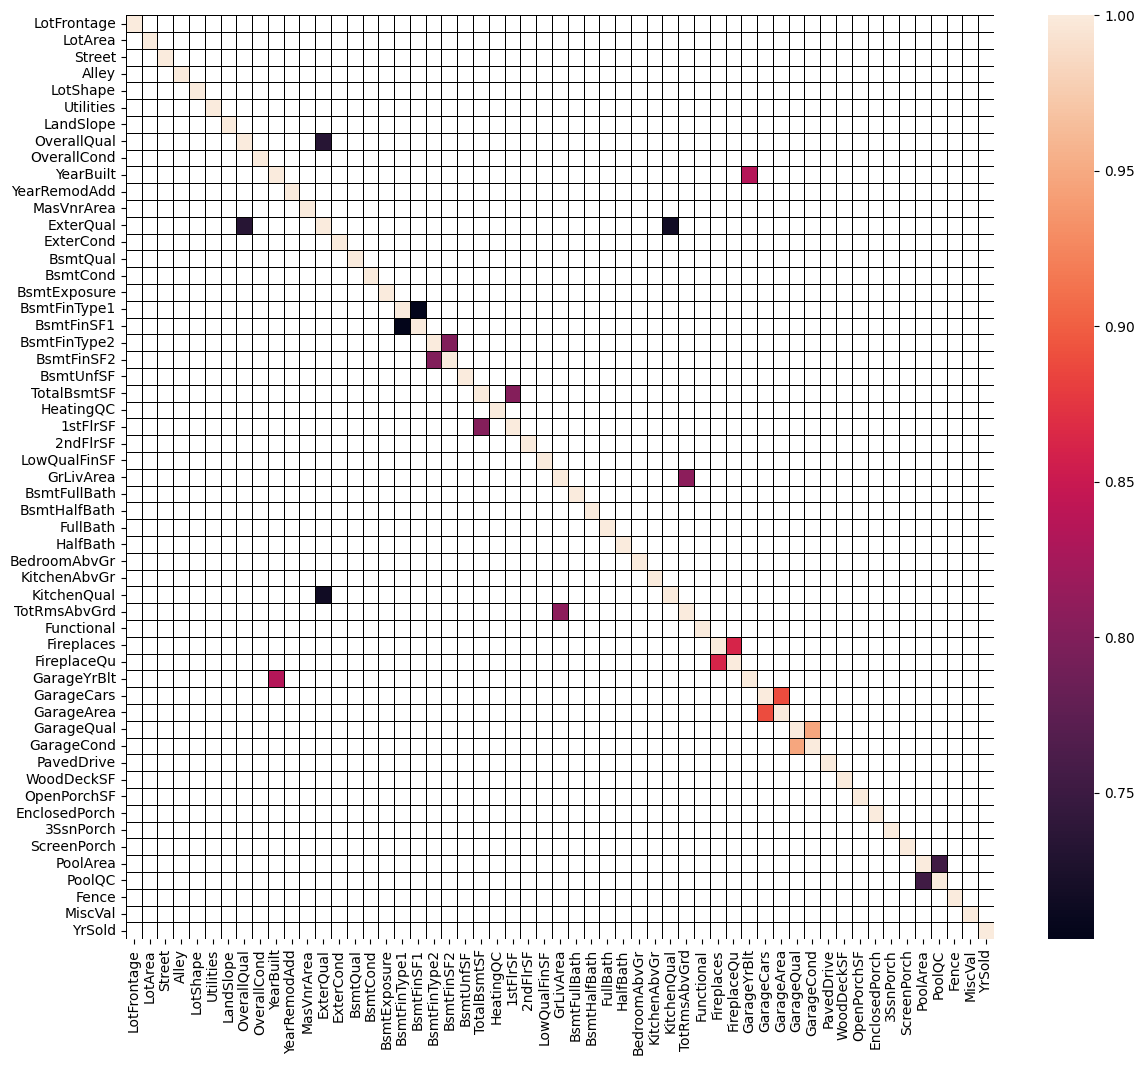

In [26]:
plt.figure(figsize=(14,12))
correlation = x_all.corr(numeric_only=True)
sns.heatmap(correlation, mask = correlation <= 0.7, linewidth=0.5, linecolor='Black')

 **Highly Correlated variables**:
* ```PoolQC``` and ```PoolArea```
* ```GarageArea``` and ```GarageCars```
* ```GarageCond``` and ```GarageQual```
* ```GarageYrBlt``` and ```YearBuilt```
* ```Fireplaces``` and ```FireplaceQu```
* ```TotRmsAbvGrd``` and ```GrLivArea```
* ```1stFlrSF``` and ```TotalBsmtSF```
* ```BsmtFinSF1``` and ```BsmtFinType1```
* ```BsmtFinSF2``` and ```BsmtFinType2```
* ```OverallQual``` and ```ExterQual```
* ```KitchenQual``` and ```ExterQual```

The high collinearity of these variables are not suprising. For example, ```GarageArea``` and ```GarageCars``` are highly correlated because they both measure the size of the garage. ```GarageArea``` measures the size in square feet, while ```GarageCars``` measures the size in terms of the number of cars that can fit. They are essentially capturing the same information, so it's not surprising that they are highly correlated.

Similarly, ```TotRmsAbvGrd``` and ```GrLivArea``` are highly correlated. ```TotRmsAbvGrd``` is the total rooms above grade (does not include bathrooms), and ```GrLivArea``` is the above grade (ground) living area in square feet. A larger living area is likely to have more rooms, so these two variables are expected to be correlated.

### Bivariate Analysis of Target and Numerical Features

In [27]:
# Retrieve the train and test data from x_all
x_train = x_all.loc[train.index]
x_test = x_all.loc[test.index]

# Combine x_train with y_train
assert x_train.shape[0] == y_train.shape[0], "Number of rows in x_train and y_train do not match"
combined = pd.concat([x_train, y_train], axis=1)

# print out correlation scores of all numeric features with the target variable
corr = combined.corr(numeric_only=True)
corr[['SalePrice']].sort_values(['SalePrice'], ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
ExterQual,0.682639
KitchenQual,0.659600
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
BsmtQual,0.585207


/Users/lowrenhwa/Desktop/house_prices_advanced_regression_techniques/.venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/Users/lowrenhwa/Desktop/house_prices_advanced_regression_techniques/.venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/Users/lowrenhwa/Desktop/house_prices_advanced_regression_techniques/.venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/Users/lowrenhwa/Desktop/house_prices_advanced_regression_techniques/.venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecate

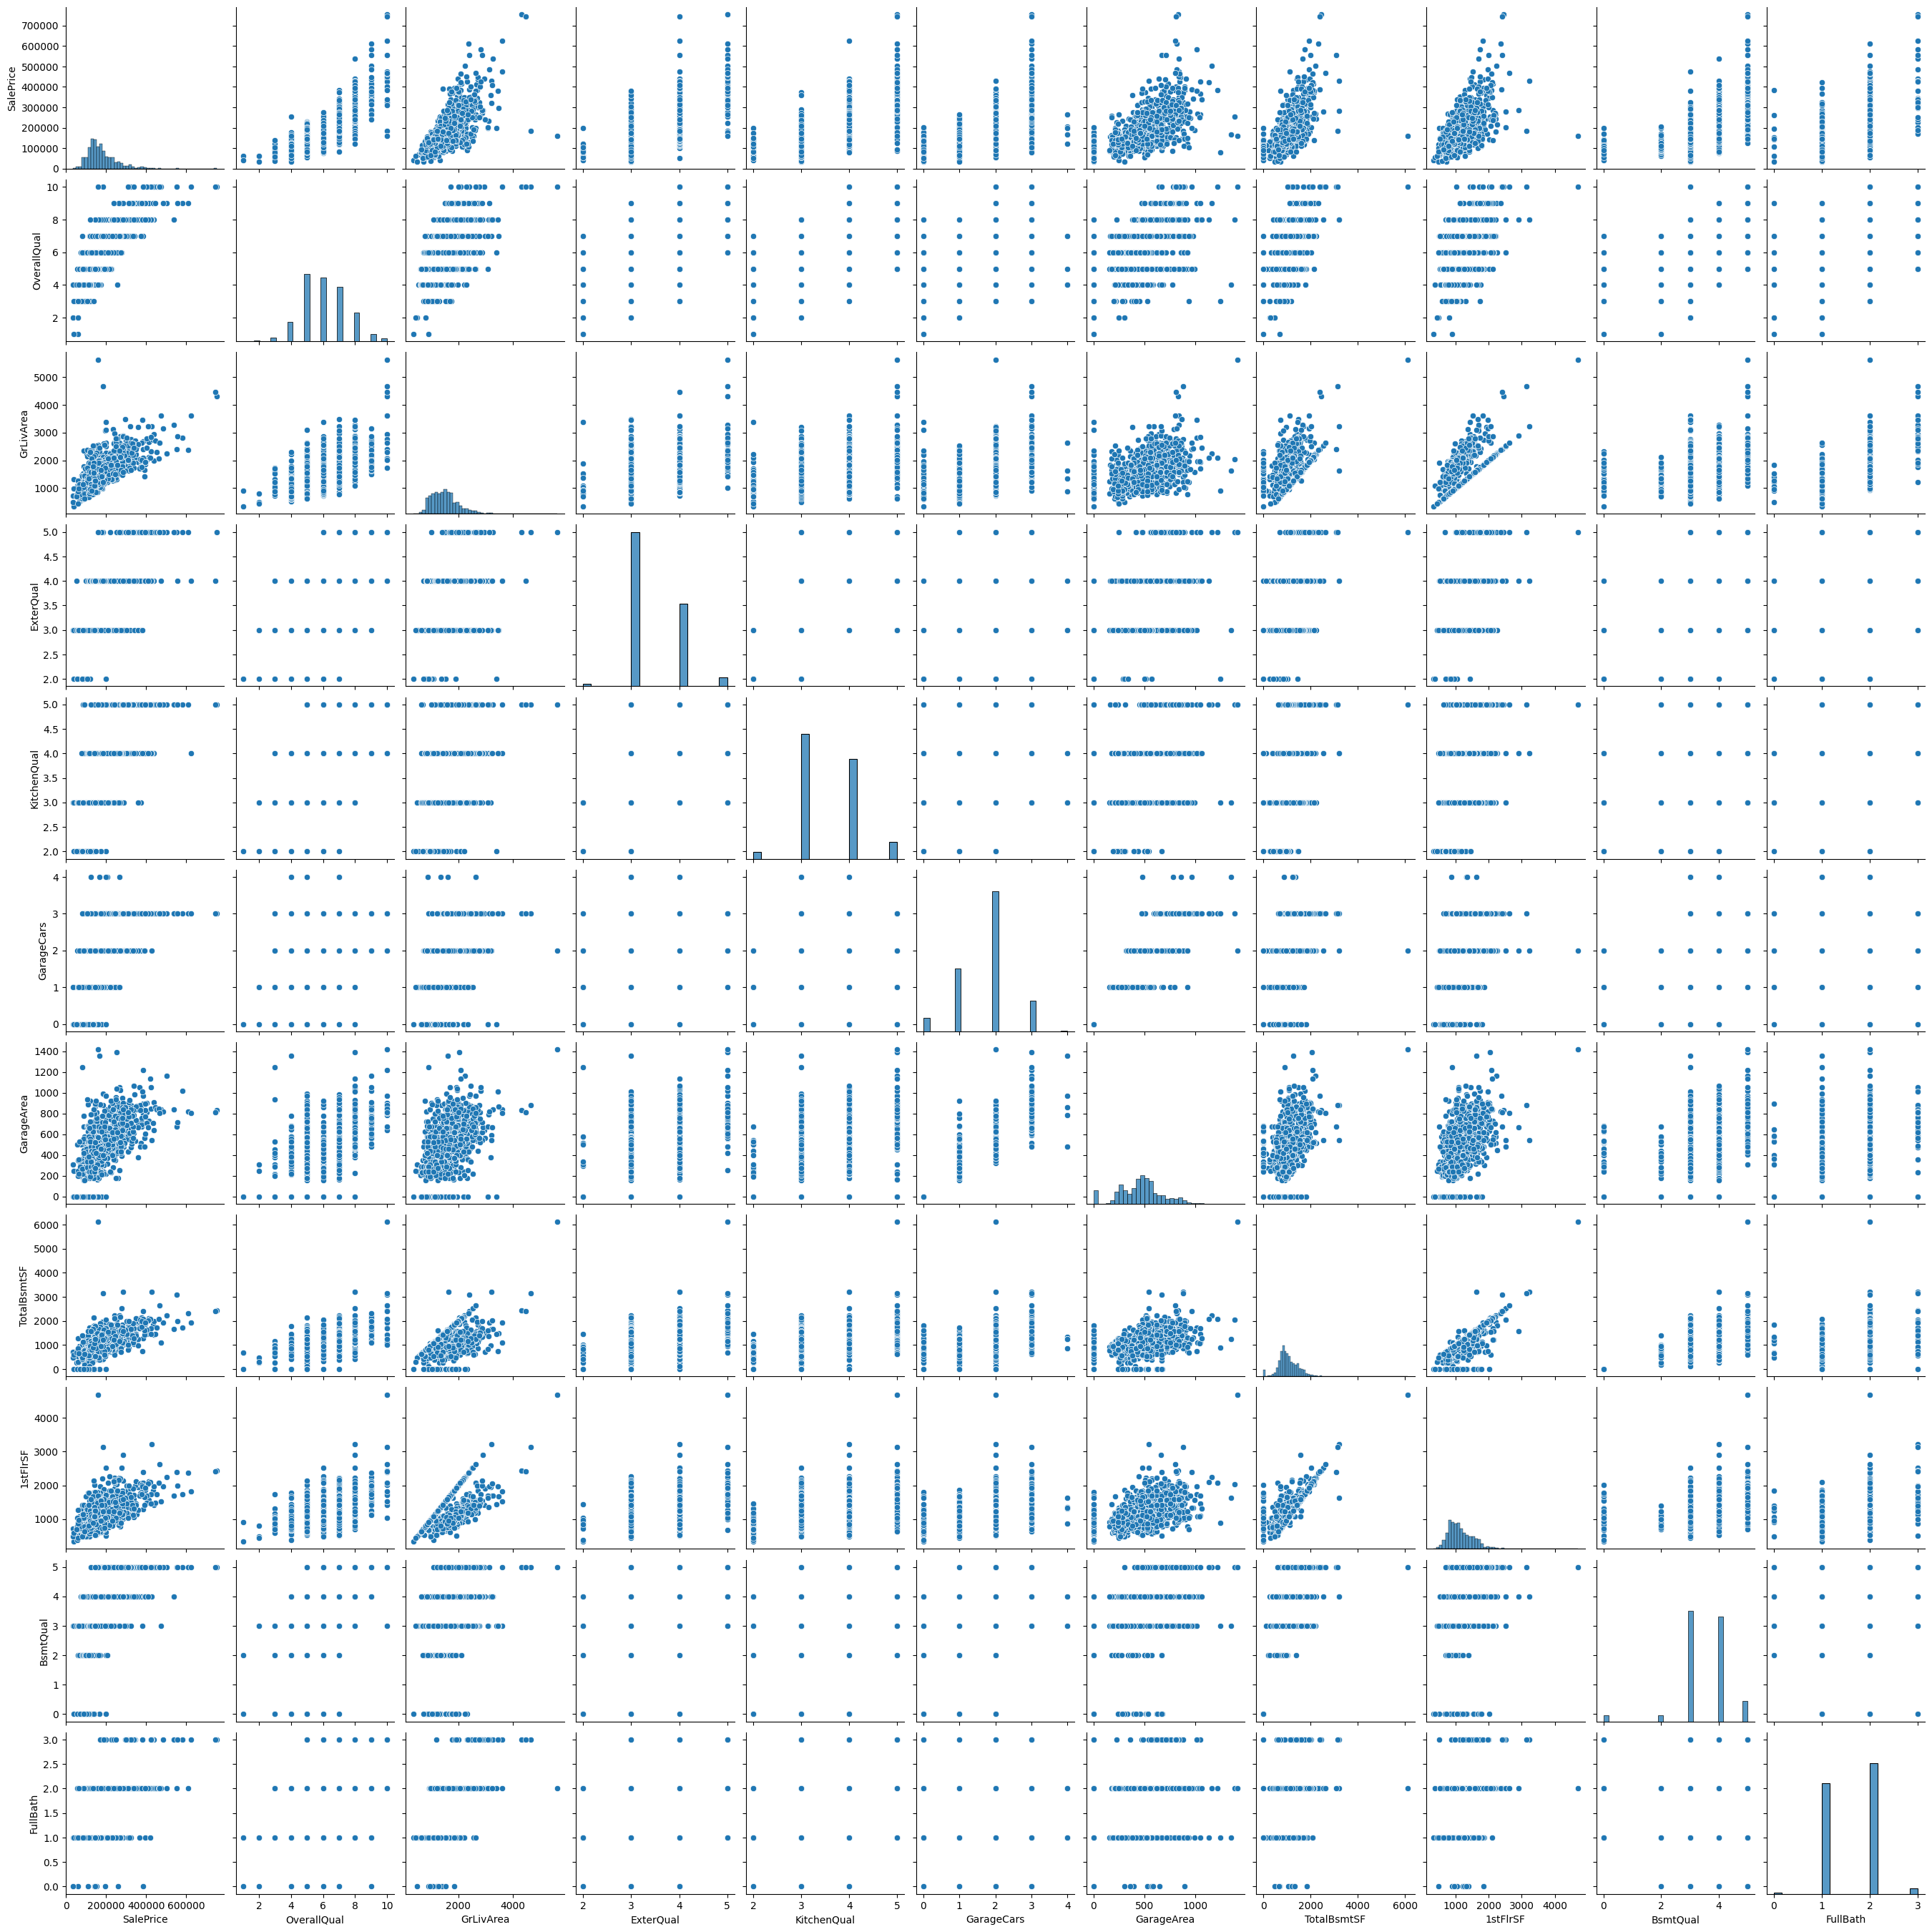

In [28]:
# Get the top 10 features most correlated with 'SalePrice'
top_10_corr_features = corr['SalePrice'].sort_values(ascending=False).head(11).index

# Create a pairplot for these features
sns.pairplot(combined[top_10_corr_features])

### Bivariate Analysis of Target and Caterogical Features

In [29]:
def bi_box_plot(data, categorical_features, target, plot_num_cols=3):
    num_plots = len(categorical_features)
    total_cols = plot_num_cols
    total_rows = num_plots // total_cols + 1

    fig = make_subplots(rows=total_rows, cols=total_cols)

    for i, var in enumerate(categorical_features):
        row = i // total_cols + 1
        pos = i % total_cols + 1
        for category in data[var].unique():
            fig.add_trace(go.Box(y=data[data[var]==category][target], name=str(category)), row=row, col=pos)

    fig.update_layout(height=300*total_rows, width=400*total_cols, title_text="Boxplot of 'SalePrice' for each category")
    fig.show()

In [30]:
bi_box_plot(combined, categorical_cols, 'SalePrice')

# Data Preprocessing
In this section, we are probably going to drop alot of variables. Thus, we can define a update_col function to keep track of which continuous, ordinal and caterogical features we dropped and keep.

In [31]:
features = {}
features['continuous'] = continuous_features
features['ordinal'] = ordinal_features
features['categorical'] = categorical_features

def update_col(features, cols_to_drop):
    features['continuous'] = [col for col in features['continuous'] if col not in cols_to_drop]
    features['ordinal'] = [col for col in features['ordinal'] if col not in cols_to_drop]
    features['categorical'] = [col for col in features['categorical'] if col not in cols_to_drop]
    
    return features

### Removing highly correlated features
It's crucial to address features with high collinearity because they can negatively impact the performance of our regression model. These highly correlated features don't provide additional information and may lead to multicollinearity issues, making it challenging for the model to discern the individual effects of each feature.

By removing these highly correlated features, we not only enhance the interpretability and stability of our regression model but also improve computational efficiency. Additionally, reducing the dimensionality of the dataset helps mitigate the curse of dimensionality, making the model more robust and less prone to overfitting.

 **Highly Correlated variables**:
* ```PoolQC``` and ```PoolArea```
* ```GarageArea``` and ```GarageCars```
* ```GarageCond``` and ```GarageQual```
* ```GarageYrBlt``` and ```YearBuilt```
* ```Fireplaces``` and ```FireplaceQu```
* ```TotRmsAbvGrd``` and ```GrLivArea```
* ```1stFlrSF``` and ```TotalBsmtSF```
* ```BsmtFinSF1``` and ```BsmtFinType1```
* ```BsmtFinSF2``` and ```BsmtFinType2```
* ```OverallQual``` and ```ExterQual```
* ```KitchenQual``` and ```ExterQual```

In [32]:
cols_to_drop = ['PoolArea', 'GarageArea', 'GarageCond', 'GarageQual', 'GarageYrBlt', 'Fireplaces', 'TotRmsAbvGrd', '1stFlrSF', 'BsmtFinType1', 'BsmtFinType2', 'ExterQual']
x_all.drop(cols_to_drop, axis=1, inplace=True)
features = update_col(features, cols_to_drop)

### Removing (almost) constant dominating features 
We remove features that exhibit little to no variability across observations, as they offer minimal discriminatory power and can hinder model performance. In this context, we set a threshold of 95% similarity across observations to identify such features.

In [33]:
def remove_overfit_features(df, threshold=0.95):
    overfit = []
    for col in df.columns:
        dominant_val_pct = df[col].value_counts(normalize=True).iloc[0]
        if dominant_val_pct > threshold:
            overfit.append(col)
    df = df.drop(overfit, axis=1)
    return df, overfit

# Apply the function to the numerical columns
x_all_num = x_all.select_dtypes(exclude=['object'])
x_all_num, overfit_num = remove_overfit_features(x_all_num)
print("Dropping these Numerical Features with >95% of the same value: ", overfit_num)

# Apply the function to the categorical columns
x_all_cat = x_all.select_dtypes(include=['object'])
x_all_cat, overfit_cat = remove_overfit_features(x_all_cat)
print("Dropping these Categorical Features with >95% of the same value: ", overfit_cat)

# Combine the processed numerical and categorical columns back into one DataFrame
x_all = pd.concat([x_all_num, x_all_cat], axis=1)
features = update_col(features, overfit_num+overfit_cat)

Dropping these Numerical Features with >95% of the same value:  ['Street', 'Utilities', 'LandSlope', 'LowQualFinSF', 'KitchenAbvGr', '3SsnPorch', 'PoolQC', 'MiscVal']
Dropping these Categorical Features with >95% of the same value:  ['Condition2', 'RoofMatl', 'Heating']


### Missing values

In [34]:
# Calculate missing data
missing_data = x_all.isnull().sum()
missing_data = missing_data[missing_data > 0]  # Only consider columns with missing data
missing_percentage = (missing_data / len(x_all)) * 100

# Combine the count and percentage into a DataFrame for nicer formatting
missing_df = pd.DataFrame({'Count': missing_data, 'Percentage': missing_percentage})

# Sort by percentage of missing values
missing_df = missing_df.sort_values(by='Percentage', ascending=False)

print("Columns with missing data, their count and percentage:")
print(missing_df)

Columns with missing data, their count and percentage:
              Count  Percentage
MiscFeature    2814   96.402878
MasVnrType     1766   60.500171
LotFrontage     486   16.649538
GarageFinish    159    5.447071
GarageType      157    5.378554
MasVnrArea       23    0.787941
MSZoning          4    0.137033
BsmtFullBath      2    0.068517
BsmtHalfBath      2    0.068517
Functional        2    0.068517
Exterior2nd       1    0.034258
Electrical        1    0.034258
GarageCars        1    0.034258
Exterior1st       1    0.034258
KitchenQual       1    0.034258
TotalBsmtSF       1    0.034258
BsmtUnfSF         1    0.034258
BsmtFinSF2        1    0.034258
BsmtFinSF1        1    0.034258
SaleType          1    0.034258


We'll drop columns with missing values exceeding 15% rather than removing rows, as the latter would lead to losing a substantial number of observations. Imputing missing values with mean or mode could introduce bias due to the high proportion of missing data. Therefore, dropping these columns helps maintain data integrity and reduces the risk of biased analysis.

In [35]:
# Identify columns where missing percentage > 15%
cols_to_drop = list(missing_percentage[missing_percentage > 15].index)
cols_to_drop.extend(['GarageFinish', 'GarageType', 'MasVnrArea'])

# Drop these columns
print(f"Dropping these columns: {', '.join(cols_to_drop)}")
x_all = x_all.drop(cols_to_drop, axis=1)
features = update_col(features, cols_to_drop)

Dropping these columns: LotFrontage, MasVnrType, MiscFeature, GarageFinish, GarageType, MasVnrArea


In [36]:
# Define the imputers
numerical_imputer = SimpleImputer(strategy='mean')
ordinal_imputer = SimpleImputer(strategy='most_frequent')
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Apply the imputers to the respective columns
x_all[features['continuous']] = numerical_imputer.fit_transform(x_all[features['continuous']])
x_all[features['ordinal']] = ordinal_imputer.fit_transform(x_all[features['ordinal']])
x_all[features['categorical']] = categorical_imputer.fit_transform(x_all[features['categorical']])

In [37]:
print(x_all.isnull().sum())

LotArea          0
Alley            0
LotShape         0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
ExterCond        0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
HeatingQC        0
2ndFlrSF         0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenQual      0
Functional       0
FireplaceQu      0
GarageCars       0
PavedDrive       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
ScreenPorch      0
Fence            0
YrSold           0
MSSubClass       0
MSZoning         0
LandContour      0
LotConfig        0
Neighborhood     0
Condition1       0
BldgType         0
HouseStyle       0
RoofStyle        0
Exterior1st      0
Exterior2nd      0
Foundation       0
CentralAir       0
Electrical       0
MoSold           0
SaleType         0
SaleCondition    0
dtype: int64


# Outliers
Outliers are unusual values in the dataset, and they can distort statistical analysis and violate their assumptions. For this reason, outlier detection and removal is usually performed before feature engineering and selection. Outliers can have many causes, such as data collection errors, data corruption, or true outlier observation - take for example, Micheal Jordan. 

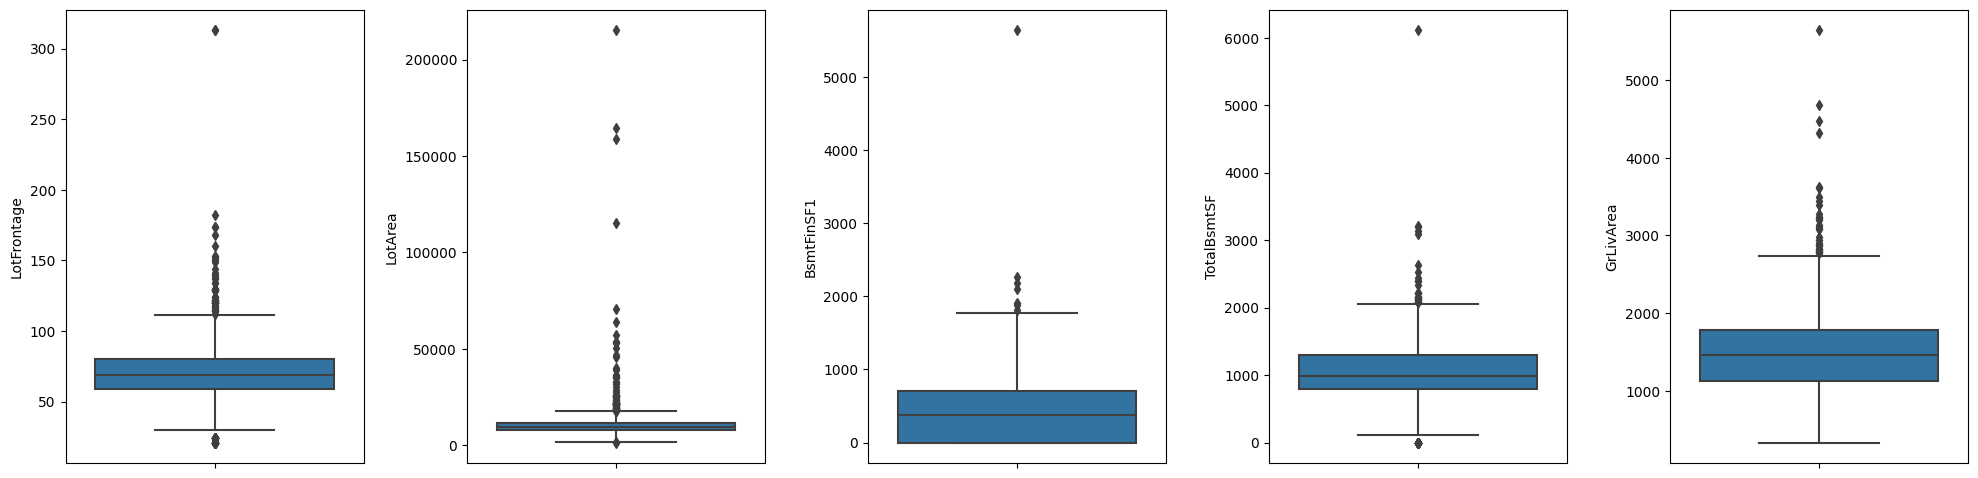

In [38]:
out_col = ['LotFrontage','LotArea','BsmtFinSF1','TotalBsmtSF','GrLivArea']
fig = plt.figure(figsize=(20,5))
for index,col in enumerate(out_col):
    plt.subplot(1,5,index+1)
    sns.boxplot(y=col, data=train)
fig.tight_layout(pad=1.5)

In [39]:
train = train.drop(train[train['LotFrontage'] > 200].index)
train = train.drop(train[train['LotArea'] > 100000].index)
train = train.drop(train[train['BsmtFinSF1'] > 4000].index)
train = train.drop(train[train['TotalBsmtSF'] > 5000].index)
train = train.drop(train[train['GrLivArea'] > 4000].index)

# Feature Engineering

### Creating New Features

In [40]:
x_all['TotalBsmtFin'] = x_all['BsmtFinSF1'] + x_all['BsmtFinSF2']
x_all['TotalSF'] = x_all['TotalBsmtSF'] + x_all['2ndFlrSF']
x_all['TotalBath'] = x_all['FullBath'] + x_all['HalfBath']
x_all['TotalPorch'] = x_all['OpenPorchSF'] + x_all['EnclosedPorch'] + x_all['ScreenPorch']

# Drop the original columns
cols_to_drop = ['BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF', '2ndFlrSF', 'FullBath', 'HalfBath', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch']
x_all.drop(columns=cols_to_drop, inplace=True)
features = update_col(features, cols_to_drop)

### Target Variable Transformation

In [41]:
log_transformed_salesprice = np.log1p(y_train["SalePrice"])

/Users/lowrenhwa/Desktop/house_prices_advanced_regression_techniques/.venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



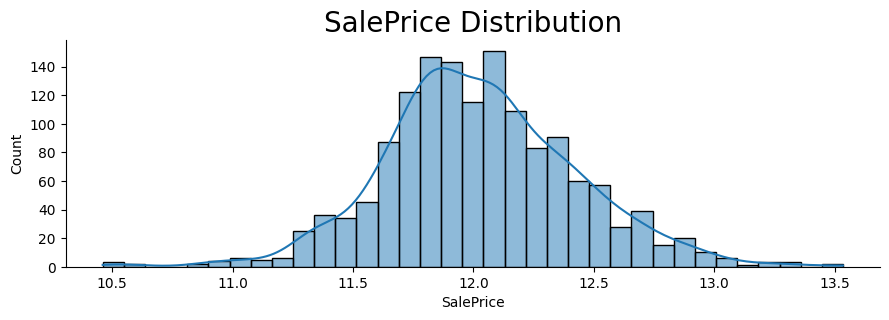

In [42]:
sns.displot(log_transformed_salesprice, kde=True, height=3, aspect=3)
plt.title('{} Distribution'.format('SalePrice'), fontsize=20)
plt.show()

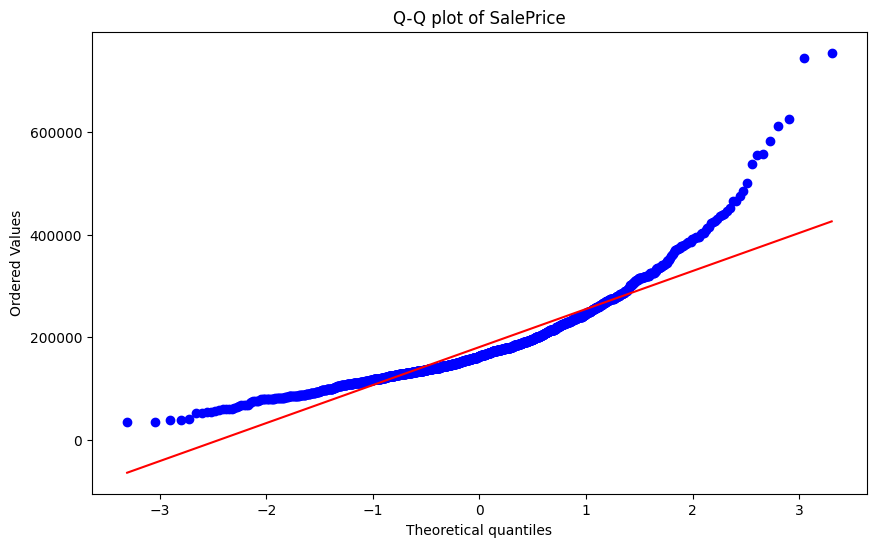

In [43]:
# Q-Q plot
plt.figure(figsize=(10, 6))
scipy.stats.probplot(log_transformed_salesprice, dist="norm", plot=plt)
plt.title('Q-Q plot of SalePrice')
plt.show()

## Feature Selection

In [44]:
def feature_selection_continuous(df, target_var, continuous_features):
    # Prepare the data
    target = df[target_var]
    df2 = df.drop([target_var], axis=1)

    # Select the numerical dataframe
    numeric_df = df2[continuous_features]

    # SelectKBest with f_regression
    selector_f_regression = SelectKBest(f_regression, k='all')
    selector_f_regression.fit_transform(numeric_df, target)
    scores_f_regression = selector_f_regression.scores_

    # Calculate Pearson's correlation coefficient for each feature
    scores_corr = numeric_df.corrwith(target)

    # Print the scores in a more readable format
    print("\nF_regression scores:")
    for score, fname in sorted(zip(scores_f_regression, continuous_features), reverse=True):
        print(f"{fname}: {score}")

    print("\nCorrelation scores:")
    for score, fname in sorted(zip(scores_corr, continuous_features), reverse=True):
        print(f"{fname}: {score}")

# Retrieve the train and test data from x_all
x_train = x_all.loc[train.index]

y_train = y_train.loc[train.index] #train[['SalePrice']]

assert x_train.shape[0] == y_train.shape[0], "Number of rows in x_train and y_train do not match"
# Combine x_train with y_train
combined = pd.concat([x_train, y_train], axis=1)

# Call the functions
feature_selection_continuous(combined, 'SalePrice', features['continuous'])


F_regression scores:
GrLivArea: 1560.0010533701736
YearBuilt: 591.979176218874
YearRemodAdd: 548.6874721042045
LotArea: 229.2084725794194
WoodDeckSF: 170.92949377549013
BsmtUnfSF: 77.08370536866626
YrSold: 0.8553572113684283

Correlation scores:
GrLivArea: 0.7200311344529048
YearBuilt: 0.5385597939726131
YearRemodAdd: 0.5240814030571302
LotArea: 0.36956631442278337
WoodDeckSF: 0.3248332272526851
BsmtUnfSF: 0.22474607390357723
YrSold: -0.02428909993931075


In [45]:
def feature_selection_categorical(df, target_var, categorical_features):
    # Prepare the data
    target = df[target_var]
    df = df.drop([target_var], axis=1)

    # Select the categorical dataframe
    categorical_df = df[categorical_features]

    # Check if the data is already encoded
    if categorical_df.applymap(np.isreal).all().all():
        categorical_df_encoded = categorical_df
    else:
        # Create a copy of the dataframe to avoid changing the original data
        categorical_df_encoded = categorical_df.copy()

        # Apply LabelEncoder to each column in the dataframe
        for column in categorical_df_encoded.columns:
            le = LabelEncoder()
            categorical_df_encoded[column] = le.fit_transform(categorical_df_encoded[column])

    # SelectKBest with mutual_info_regression
    selector_mutual_info_regression = SelectKBest(mutual_info_regression, k='all')
    selector_mutual_info_regression.fit_transform(categorical_df_encoded, target)
    scores_mutual_info_regression = selector_mutual_info_regression.scores_

    # Print the scores in a more readable format
    print("\nMutual_info_regression scores:")
    for score, fname in sorted(zip(scores_mutual_info_regression, categorical_df_encoded.columns), reverse=True):
        print(f"{fname}: {score}")
        
feature_selection_categorical(combined, 'SalePrice', features['categorical'])


Mutual_info_regression scores:
Neighborhood: 0.5052303268304623
MSSubClass: 0.2781413369599832
Foundation: 0.21833575086213064
Exterior2nd: 0.15841390157176605
Exterior1st: 0.1370933804694121
MSZoning: 0.12346410501574723
HouseStyle: 0.08826992150938962
SaleType: 0.07933554482838234
SaleCondition: 0.07642845729342151
CentralAir: 0.060562711700979266
Electrical: 0.04439120224255699
BldgType: 0.03360801714892281
Condition1: 0.019410394908027317
RoofStyle: 0.019397750991495766
LotConfig: 0.011175759144137043
LandContour: 0.010151246032285899
MoSold: 0.0


/var/folders/d4/5l4xnmvj49sdyj0yn_kllq740000gn/T/ipykernel_38379/3066713933.py:10: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [46]:
feature_selection_categorical(combined, 'SalePrice', features['ordinal'])


Mutual_info_regression scores:
OverallQual: 0.5753288096853582
GarageCars: 0.35654545564836426
BsmtQual: 0.3329705805069745
KitchenQual: 0.328106710248244
FireplaceQu: 0.1952668093627501
HeatingQC: 0.1706705629348697
OverallCond: 0.10450278276412472
LotShape: 0.0833544106308548
BsmtExposure: 0.0797332447194623
BedroomAbvGr: 0.07014725681230471
BsmtCond: 0.0635982109753972
PavedDrive: 0.04771602251638152
Fence: 0.0457250725812417
BsmtFullBath: 0.024022892425573206
Alley: 0.019401874518189643
ExterCond: 0.016257181226750017
BsmtHalfBath: 0.01608088960307974
Functional: 0.0


/var/folders/d4/5l4xnmvj49sdyj0yn_kllq740000gn/T/ipykernel_38379/3066713933.py:10: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



# Quick Model Scoping with pycaret

In [47]:
from pycaret.regression import *

In [48]:
ordinal_features = {}

for feature in features['ordinal']:
    # Get unique values for the feature
    unique_values = sorted(combined[feature].unique())
    
    # Check if all unique values are integers (when converted from float)
    non_integer_values = [value for value in unique_values if not float(value).is_integer()]
    
    if non_integer_values:
        print(f"Feature {feature} contains non-integer values: {non_integer_values}")
    else:
        # Convert the unique values to integers and add the feature to the dictionary
        ordinal_features[feature] = [int(value) for value in unique_values]
        
exp1 = setup(combined, 
             target='SalePrice', 
             numeric_features=features['continuous'], 
             categorical_features=features['categorical'],
             ordinal_features=ordinal_features,
             transform_target = True,
             transform_target_method = 'yeo-johnson',
             #transformation = True,
             #transformation_method='yeo-johnson',
             normalize = True,
             normalize_method = 'zscore',#'robust',
            #  feature_selection=True,
            #  feature_selection_method='univariate',
            #  n_features_to_select= 0.8,
            #  remove_multicollinearity = True,
            #  multicollinearity_threshold = 0.8,
            #  pca = True,
            #  pca_method='linear',
            #  pca_components=0.7,
            #  low_variance_threshold= 0.8,
             session_id=123)

,Description,Value
0,Session id,123
1,Target,SalePrice
2,Target type,Regression
3,Original data shape,"(1451, 47)"
4,Transformed data shape,"(1451, 179)"
5,Transformed train set shape,"(1015, 179)"
6,Transformed test set shape,"(436, 179)"
7,Ordinal features,18
8,Numeric features,7
9,Categorical features,17


In [49]:
# Compare machine learning models
best = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,13251.2782,375740387.3538,19096.3810,0.9315,0.1085,0.0782,0.0450
ridge,Ridge Regression,13483.5386,385924393.2025,19373.9722,0.9295,0.1097,0.0792,0.0440
huber,Huber Regressor,13493.4210,398479594.0491,19662.4599,0.9275,0.1107,0.0795,0.0490
catboost,CatBoost Regressor,13529.5897,413707662.4960,20039.9588,0.9241,0.1098,0.0793,0.4160
omp,Orthogonal Matching Pursuit,14559.8916,433985289.0854,20656.7008,0.9187,0.1138,0.0844,0.0410
lightgbm,Light Gradient Boosting Machine,14560.0366,469068873.9971,21435.5870,0.9126,0.1219,0.0870,0.2720
gbr,Gradient Boosting Regressor,14791.3372,471522015.8505,21494.6073,0.9124,0.1194,0.0865,0.1050
par,Passive Aggressive Regressor,15975.7620,500798222.3520,22199.4561,0.9065,0.1275,0.0943,0.0470
xgboost,Extreme Gradient Boosting,16196.6686,575283388.8941,23789.1744,0.8922,0.1268,0.0943,0.0800
et,Extra Trees Regressor,16172.2079,601284767.8900,24270.0946,0.8886,0.1293,0.0939,0.1770


# Modelling

In [50]:
# Standard library imports
from math import sqrt
from tempfile import mkdtemp
from shutil import rmtree
import itertools

# Third party imports
import prince
from numpy import log1p, exp
from scipy.special import inv_boxcox, boxcox1p, inv_boxcox1p
from scipy.stats import yeojohnson

# Scikit-learn imports for preprocessing and transformation
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.preprocessing import QuantileTransformer, PowerTransformer, FunctionTransformer
from sklearn.decomposition import PCA

# Scikit-learn imports for models
from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor

# Other model imports
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from mlxtend.regressor import StackingRegressor

# Scikit-learn imports for model selection and evaluation
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

In [51]:
x = x_all.loc[train.index]
y = y_train.loc[train.index]
test = x_all.loc[test.index]

X_train, X_val, Y_train, Y_val = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Train has {x_train.shape[0]} rows and {x_train.shape[1]} columns")
print(f"Test has {test.shape[0]} rows and {test.shape[1]} columns")

Train has 1451 rows and 46 columns
Test has 1459 rows and 46 columns


In [52]:
transformation_method = "boxcox"

if transformation_method == "log":
    transformer = FunctionTransformer(func=log1p, inverse_func=exp, validate=True)
elif transformation_method == "yeojohnson":
    transformer = PowerTransformer(method='yeo-johnson')
elif transformation_method == "boxcox":
    transformer = FunctionTransformer(func=lambda x: boxcox1p(x, 0.15), inverse_func=lambda x: inv_boxcox1p(x, 0.15), validate=True)
elif transformation_method == "quantile":
    transformer = QuantileTransformer(output_distribution='uniform', random_state=0)
elif transformation_method == "none":
    transformer = FunctionTransformer(func=lambda x: x, inverse_func=lambda x: x, validate=True)
else:
    raise ValueError(f"Unknown transformation method: {transformation_method}")

In [53]:
def evaluate_model(y_pred, y_truth):    
    mae = mean_absolute_error(y_truth, y_pred)
    mse = mean_squared_error(y_truth, y_pred)
    rmse = sqrt(mse)
    r2 = r2_score(y_truth, y_pred)
    
    print(f'MAE: {mae}')
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'R2: {r2}')

    return {'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2}

results = {} #empty dictionary to store the results

In [54]:
# Define preprocessing for numeric columns (scale them and then apply PCA)
numeric_transformer = make_pipeline(StandardScaler()) #make_pipeline(RobustScaler())  #  make_pipeline(RobustScaler(), PCA(n_components=5))change n_components to the number of principal components you want

# Define preprocessing for categorical columns (one-hot encode them)
categorical_transformer = make_pipeline(OneHotEncoder(sparse_output=False, handle_unknown='ignore')) #prince.MCA()

# Define preprocessing for ordinal columns (ordinal encode them)
ordinal_transformer = make_pipeline(OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value= -1)) #prince.MCA()

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features['continuous']),
        ('cat', categorical_transformer, features['categorical']),
        ('ord', ordinal_transformer, features['ordinal'])
    ])

# Create a temporary folder to cache the transformers
cachedir = mkdtemp()

### Bayesian Ridge

In [55]:
# Bayesian Ridge Regression
bayesian_ridge = BayesianRidge()
bayesian_ridge_pipeline = make_pipeline(preprocessor, bayesian_ridge, memory=cachedir)
bayesian_ridge_params = {
    'bayesianridge__alpha_1' : [1e-7, 1e-6, 1e-5, 1e-4],
    'bayesianridge__alpha_2' : [1e-7, 1e-6, 1e-5, 1e-4],
    'bayesianridge__lambda_1' : [1e-7, 1e-6, 1e-5, 1e-4],
    'bayesianridge__lambda_2' : [1e-7, 1e-6, 1e-5, 1e-4],
    'bayesianridge__max_iter' : [100, 200, 300, 400, 500]
}

random_search = RandomizedSearchCV(estimator=bayesian_ridge_pipeline, 
                                   param_distributions=bayesian_ridge_params, 
                                   n_iter=100, 
                                   cv=5, 
                                   n_jobs=-1, 
                                   refit=True, 
                                   scoring="neg_mean_squared_error")

regr_bayesian_ridge = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_bayesian_ridge.fit(X_train, Y_train)

Y_pred = regr_bayesian_ridge.predict(X_val)
results["bayesian_ridge"] = evaluate_model(Y_pred, Y_val)

MAE: 14330.92281001285
MSE: 410319689.1582925
RMSE: 20256.349354172693
R2: 0.9151594338853057


### Ridge Regression

In [56]:
# Ridge Regression
ridge = Ridge()
ridge_pipeline = make_pipeline(preprocessor, ridge, memory=cachedir)
ridge_params = {
    'ridge__alpha' : [0.1, 0.5, 1.0, 2.0, 5.0],
    'ridge__solver' : ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
}

random_search = RandomizedSearchCV(estimator=ridge_pipeline, 
                                   param_distributions=ridge_params, 
                                   n_iter=100, 
                                   cv=5, 
                                   n_jobs=-1, 
                                   refit=True, 
                                   scoring="neg_mean_squared_error")

regr_ridge = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_ridge.fit(X_train, Y_train)

Y_pred = regr_ridge.predict(X_val)
results["ridge"] = evaluate_model(Y_pred, Y_val)

MAE: 14332.223754975808
MSE: 412275001.1580318
RMSE: 20304.55616747216
R2: 0.9147551399131373


### CatBoost

In [57]:
catboost = CatBoostRegressor(logging_level='Silent')

catboost_pipeline = make_pipeline(preprocessor, catboost, memory=cachedir)

catboost_params = {
    'catboostregressor__n_estimators' : [100, 300, 500, 1000, 1300, 1600],
    'catboostregressor__learning_rate' : [0.0001, 0.001, 0.01, 0.1],
    'catboostregressor__l2_leaf_reg' : [0.001, 0.01, 0.1],
    'catboostregressor__random_strength' : [0.25, 0.5 ,1],
    'catboostregressor__max_depth' : [3, 6, 9],
    'catboostregressor__min_child_samples' : [2, 5, 10, 15, 20],
    'catboostregressor__rsm' : [0.5, 0.7, 0.9],
    'catboostregressor__bagging_temperature' : [0, 0.5, 1],
    'catboostregressor__border_count' : [32, 64, 128, 255]
}
random_search = RandomizedSearchCV(estimator=catboost_pipeline, 
                                   param_distributions=catboost_params, 
                                   n_iter=100, 
                                   cv=5, 
                                   n_jobs=-1, 
                                   refit=True, 
                                   scoring="neg_mean_squared_error")

regr_catboost = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_catboost.fit(X_train, Y_train)  

Y_pred = regr_catboost.predict(X_val)
results["catboost"] = evaluate_model(Y_pred, Y_val)

MAE: 14769.667935552447
MSE: 426397177.4596926
RMSE: 20649.386854327964
R2: 0.9118351400597006


### GradientBoosting

In [58]:
gbr = GradientBoostingRegressor(n_estimators=3000, 
                                learning_rate=0.05,
                                max_depth=4,
                                max_features='sqrt',
                                min_samples_leaf=15,
                                min_samples_split=10, 
                                loss='huber',
                                random_state =5)

gbr_pipeline = make_pipeline(preprocessor, gbr, memory=cachedir)

gbr_params = {
    'gradientboostingregressor__learning_rate' : [0.01, 0.1, 0.15, 0.3, 0.5],
    'gradientboostingregressor__n_estimators' : [100, 500, 1000, 2000, 3000],
    'gradientboostingregressor__max_depth' : [3, 6, 9],
    'gradientboostingregressor__min_samples_split' : [2, 5, 10],
    'gradientboostingregressor__min_samples_leaf' : [1, 2, 5]
}

random_search = RandomizedSearchCV(estimator=gbr_pipeline, 
                                   param_distributions=gbr_params, 
                                   n_iter=100, 
                                   cv=5, 
                                   n_jobs=-1, 
                                   refit=True, 
                                   scoring="neg_mean_squared_error")

regr_gbr = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_gbr.fit(X_train, Y_train)

Y_pred = regr_gbr.predict(X_val)
results["gbc"] = evaluate_model(Y_pred, Y_val)

MAE: 14622.550923639134
MSE: 430539889.33145815
RMSE: 20749.455157460357
R2: 0.9109785640051329


### LightGBM

In [59]:
lgbm = LGBMRegressor(boosting_type='gbdt',
                     objective='regression',
                     max_depth=-1,
                     lambda_l1=0.0001,
                     lambda_l2=0, 
                     learning_rate=0.1,
                     n_estimators=100,
                     max_bin=200, 
                     min_child_samples=20, 
                     bagging_fraction=0.75,
                     bagging_freq=5,
                     bagging_seed=7,
                     feature_fraction=0.8,
                     feature_fraction_seed=7,
                     verbose=-1)

lgbm_pipeline = make_pipeline(preprocessor, lgbm, memory=cachedir)

lgbm_params = {
    'lgbmregressor__max_depth' : [3, 5, 8, 10],
    'lgbmregressor__learning_rate' : [0.001, 0.01, 0.1, 0.2],
    'lgbmregressor__n_estimators' : [100, 300, 500, 1000, 1500],
    'lgbmregressor__lambda_l1' : [0.0001, 0.001, 0.01],
    'lgbmregressor__lambda_l2' : [0, 0.0001, 0.001, 0.01],
    'lgbmregressor__feature_fraction' : [0.4, 0.6, 0.8],
    'lgbmregressor__min_child_samples' : [5, 10, 20, 25],
    'lgbmregressor__num_leaves' : [31, 62, 124, 248],
    'lgbmregressor__min_split_gain' : [0.0, 0.1, 0.2]
}

random_search = RandomizedSearchCV(estimator=lgbm_pipeline, 
                                   param_distributions=lgbm_params, 
                                   n_iter=100, 
                                   cv=5, 
                                   n_jobs=-1, 
                                   refit=True, 
                                   scoring="neg_mean_squared_error")

regr_lgbm = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_lgbm.fit(X_train, Y_train)

Y_pred = regr_lgbm.predict(X_val)
results["lightgbm"] = evaluate_model(Y_pred, Y_val)

/Users/lowrenhwa/Desktop/house_prices_advanced_regression_techniques/.venv/lib/python3.9/site-packages/sklearn/pipeline.py:408: UserWarning: Persisting input arguments took 0.52s to run.If this happens often in your code, it can cause performance problems (results will be correct in all cases). The reason for this is probably some large input arguments for a wrapped function.
  X, fitted_transformer = fit_transform_one_cached(


MAE: 15002.303024635385
MSE: 454990167.9341014
RMSE: 21330.498539277076
R2: 0.9059230535504298


### Stacking Meta Learner

In [60]:
def get_best_model(regr, model_name):
    best_params = regr.regressor_.best_estimator_.named_steps[model_name].get_params()
    best_params = {key.replace(f'{model_name}__', ''): value for key, value in best_params.items()}
    best_model = clone(regr.regressor_.best_estimator_.named_steps[model_name])
    best_model.set_params(**best_params)
    return best_model

# Get the best models
best_bayesian_ridge_model = get_best_model(regr_bayesian_ridge, 'bayesianridge')
best_ridge_model = get_best_model(regr_ridge, 'ridge')
best_catboost_model = get_best_model(regr_catboost, 'catboostregressor')
best_gbr_model = get_best_model(regr_gbr, 'gradientboostingregressor')
best_lgmb_model = get_best_model(regr_lgbm, 'lgbmregressor')

# Define the base models
base_models = [best_bayesian_ridge_model, best_ridge_model, best_catboost_model, best_gbr_model, best_lgmb_model]
base_models_names = ['catboost', 'gbr', 'lgbm', 'ridge', 'bayesian_ridge']

# Create the stacking model
stacked_model = StackingRegressor(regressors=base_models,
                                  meta_regressor=best_bayesian_ridge_model,
                                  use_features_in_secondary=True)

stacked_pipeline = make_pipeline(preprocessor, stacked_model, memory=cachedir)

# Define the parameter grid
param_grid = {
    'stackingregressor__regressors': [combo for r in range(2, 6) for combo in itertools.combinations(base_models, r)],
    'stackingregressor__meta_regressor': base_models
}

# Create the grid search object
grid = GridSearchCV(estimator=stacked_pipeline, 
                    param_grid=param_grid, 
                    cv=5, 
                    n_jobs=-1, 
                    refit=True, 
                    scoring="neg_mean_squared_error")

# Fit the grid search
grid.fit(X_train, Y_train)

# Get the best model
best_stacked_model = grid.best_estimator_

# Predict on the validation set
Y_pred = best_stacked_model.predict(X_val)

# Evaluate the model
results["stacked_model"] = evaluate_model(Y_pred, Y_val)

/Users/lowrenhwa/Desktop/house_prices_advanced_regression_techniques/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/lowrenhwa/Desktop/house_prices_advanced_regression_techniques/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/lowrenhwa/Desktop/house_prices_advanced_regression_techniques/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/lowrenhwa/Deskt

MAE: 14575.654549774494
MSE: 455862913.11602366
RMSE: 21350.946422021287
R2: 0.905742598658148


### Voting Regressor

In [61]:
# Define the base models
base_models = [
    ('ridge', best_ridge_model),
    ('bayesian_ridge', best_bayesian_ridge_model),
    ('gbr', best_gbr_model),
    ('catboost', best_catboost_model),
    ('lgbm', best_lgmb_model),
    #('stacked', best_stacked_model)
]

# Create the voting model
voting_model = VotingRegressor(estimators=base_models)

voting_pipeline = make_pipeline(preprocessor, voting_model, memory=cachedir)

# Fit the voting model on the training data
voting_pipeline.fit(X_train, Y_train)

# Predict the target on the validation data
Y_pred = voting_pipeline.predict(X_val)

# Evaluate the model
results["voting_regressor"] = evaluate_model(Y_pred, Y_val)

MAE: 14454.390806670654
MSE: 420342446.80722123
RMSE: 20502.254676186745
R2: 0.91308705847795


In [62]:
# Predict the target on the test data
subm = voting_pipeline.predict(test)

# Create the submission DataFrame
submission = pd.DataFrame({'Id': test.index+1, 'SalePrice': subm})

# Save the submission DataFrame to a CSV file
submission.to_csv(f'data/submission/voting_results_{transformation_method}.csv', index=False)
submission

,Id,SalePrice
0,1461,118981.810594
1,1462,165440.252080
2,1463,180335.083284
3,1464,189972.146689
4,1465,190031.666019
...,...,...
1454,2915,81928.712322
1455,2916,75403.154332
1456,2917,156227.241524
1457,2918,108559.141899


In [63]:
results

{'bayesian_ridge': {'mae': 14330.92281001285,
  'mse': 410319689.1582925,
  'rmse': 20256.349354172693,
  'r2': 0.9151594338853057},
 'ridge': {'mae': 14332.223754975808,
  'mse': 412275001.1580318,
  'rmse': 20304.55616747216,
  'r2': 0.9147551399131373},
 'catboost': {'mae': 14769.667935552447,
  'mse': 426397177.4596926,
  'rmse': 20649.386854327964,
  'r2': 0.9118351400597006},
 'gbc': {'mae': 14622.550923639134,
  'mse': 430539889.33145815,
  'rmse': 20749.455157460357,
  'r2': 0.9109785640051329},
 'lightgbm': {'mae': 15002.303024635385,
  'mse': 454990167.9341014,
  'rmse': 21330.498539277076,
  'r2': 0.9059230535504298},
 'stacked_model': {'mae': 14575.654549774494,
  'mse': 455862913.11602366,
  'rmse': 21350.946422021287,
  'r2': 0.905742598658148},
 'voting_regressor': {'mae': 14454.390806670654,
  'mse': 420342446.80722123,
  'rmse': 20502.254676186745,
  'r2': 0.91308705847795}}

## Blending

In [64]:
def blend_models(models, X, weights):
    """Blend the predictions of multiple models by averaging them, with weights."""
    # Make predictions with each model
    predictions = [model.predict(X).ravel() for model in models]
    
    # Blend the predictions by averaging them, with weights
    blended_predictions = np.average(predictions, axis=0, weights=weights)
    
    return blended_predictions

# Define weights for each model
rmse_values = [results[model]["rmse"] for model in ["bayesian_ridge", "ridge", "catboost", "gbc", "lightgbm", "stacked_model", "voting_regressor"]]

# Compute weights as the inverse of the RMSE
weights = [1 / rmse for rmse in rmse_values]

# Normalize the weights so they sum to 1
weights = [weight / sum(weights) for weight in weights]

# Use the blend_models function to make predictions on the validation set
Y_Pred = blend_models([regr_bayesian_ridge, regr_ridge, regr_catboost, regr_gbr, regr_lgbm, best_stacked_model, voting_pipeline], X_val, weights)

# Evaluate the blended model
evaluate_model(Y_Pred, Y_val)

MAE: 13940.576272832863
MSE: 394935975.46557236
RMSE: 19872.99613710958
R2: 0.9183402780249426


{'mae': 13940.576272832863,
 'mse': 394935975.46557236,
 'rmse': 19872.99613710958,
 'r2': 0.9183402780249426}

In [65]:
subm = blend_models([regr_bayesian_ridge, regr_ridge, regr_catboost, regr_gbr, regr_lgbm, best_stacked_model, voting_pipeline], test, weights)
submission = pd.DataFrame({'Id': test.index +1,
                           'SalePrice': subm})
submission.to_csv(f'data/submission/blending_results_{transformation_method}.csv', index=False)
submission

,Id,SalePrice
0,1461,119674.067509
1,1462,158330.048204
2,1463,178424.207936
3,1464,191892.205640
4,1465,184325.030378
...,...,...
1454,2915,88801.358570
1455,2916,84427.075555
1456,2917,159181.273640
1457,2918,113475.107582


## Best model with lowest RMSE

In [66]:
subm = regr_gbr.predict(test).ravel()
submission = pd.DataFrame({'Id': test.index +1,
                           'SalePrice': subm})
submission.to_csv(f'data/submission/gbr_results_{transformation_method}.csv', index=False)
submission

,Id,SalePrice
0,1461,121064.650437
1,1462,156181.644585
2,1463,184243.303041
3,1464,194689.666720
4,1465,174740.429303
...,...,...
1454,2915,90080.911788
1455,2916,88639.041461
1456,2917,167306.904006
1457,2918,117081.985860
